Jacobi did not converge within max_iter=200 for tol=0.001
Jacobi did not converge within max_iter=200 for tol=1e-06
Jacobi did not converge within max_iter=200 for tol=1e-09
Jacobi tol=0.001, iterations=200
[0.56761202 0.5673876  0.56735727 0.56747687 0.5677695 ]

Jacobi tol=1e-06, iterations=200
[0.56761202 0.5673876  0.56735727 0.56747687 0.5677695 ]

Jacobi tol=1e-09, iterations=200
[0.56761202 0.5673876  0.56735727 0.56747687 0.5677695 ]

Gauss-Seidel tol=0.001, iterations=9
[0.99878866 1.00118556 0.99911196 1.00064641 0.9996504 ]

Gauss-Seidel tol=1e-06, iterations=21
[0.99999926 1.00000045 0.99999989 0.99999997 1.00000005]

Gauss-Seidel tol=1e-09, iterations=30
[1. 1. 1. 1. 1.]

Tolerance | Jacobi Iters | Gauss-Seidel Iters
0.001 | 200 | 9
1e-06 | 200 | 21
1e-09 | 200 | 30


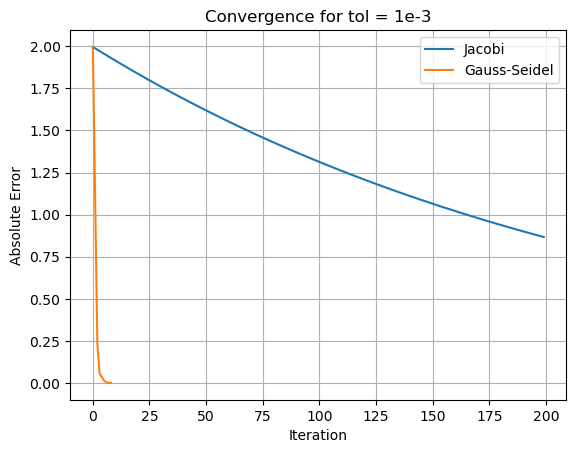

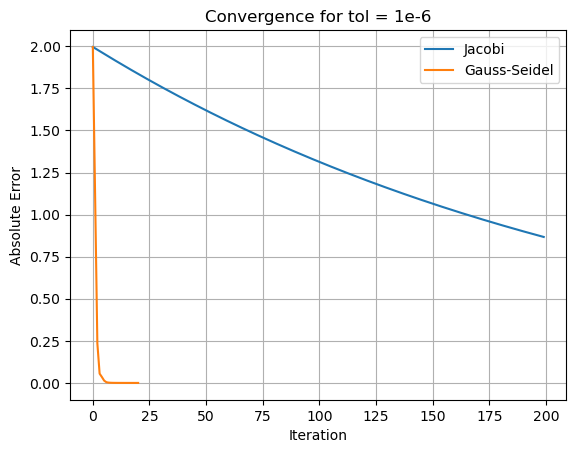

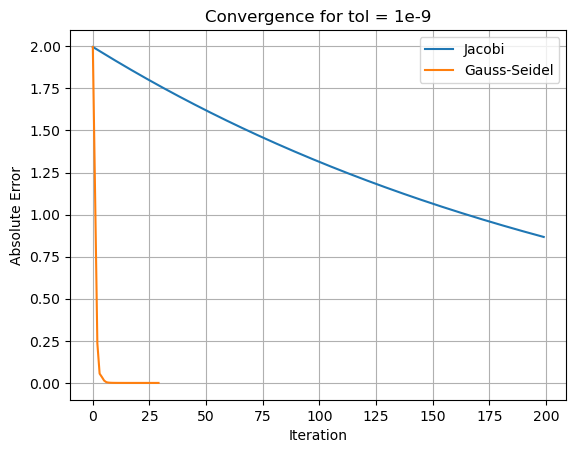

In [6]:
import numpy as np
import matplotlib.pyplot as plt
A = np.array([
    [0.582745, 0.48    , 0.10    , 0.      , 0.      ],
    [0.48    , 1.044129, 0.46    , 0.10    , 0.      ],
    [0.10    , 0.46    , 1.10431 , 0.44    , 0.10    ],
    [0.      , 0.10    , 0.44    , 0.963889, 0.42    ],
    [0.      , 0.      , 0.10    , 0.42    , 0.522565]
], dtype=float)
b = np.array([1.162745, 2.084129, 2.20431, 1.923889, 1.042565], dtype=float)
tol = np.array([10**-3, 10**-6, 10**-9], dtype=float)
def Jacobi(A, b, tol, xs_by_tol, errors_by_tol, max_iter=200):
    if b.ndim == 2 and b.shape[1] == 1:
        b = b[:, 0]
    for k in range(tol.shape[0]):
        isConverged = False
        x = np.zeros(A.shape[0])     
        errors = []
        xs = [x.copy()]
        it = 0
        while (not isConverged) and it < max_iter:
            x_update = np.zeros(A.shape[0])
            ATermsArray = np.zeros(A.shape[0])
            for i in range(A.shape[0]):
                for j in range(A.shape[1]):
                    if (i == j):
                        continue
                    ATermsArray[i] += A[i][j] * (x[j])
                x_update[i] = (b[i] - ATermsArray[i]) / A[i][i]
            changes = np.zeros(A.shape[0])
            for i in range(A.shape[0]):
                changes[i] = x_update[i] - x[i]
            err = np.max(np.abs(changes))
            if err < tol[k]:
                isConverged = True
            errors.append(err)
            x = x_update
            xs.append(x.copy())
            it += 1
        if not isConverged:
            print("Jacobi did not converge within max_iter=" + str(max_iter) + " for tol=" + str(tol[k]))
        errors_by_tol.append(errors)
        xs_by_tol.append(xs)
    return xs_by_tol, errors_by_tol
def GaussSeidel(A, b, tol, xs_by_tol, errors_by_tol, max_iter=100000):
    if b.ndim == 2 and b.shape[1] == 1:
        b = b[:, 0]
    for k in range(tol.shape[0]):
        isConverged = False
        x = np.zeros(A.shape[0])
        errors = []
        xs = [x.copy()]
        it = 0
        while (not isConverged) and it < max_iter:
            x_update = np.zeros(A.shape[0])
            ATermsArray = np.zeros(A.shape[0])
            for i in range(A.shape[0]):
                for j in range(A.shape[1]):
                    if (i == j):
                        continue
                    if (j < i):
                        ATermsArray[i] += A[i][j] * (x_update[j])
                    else:
                        ATermsArray[i] += A[i][j] * (x[j])
                x_update[i] = (b[i] - ATermsArray[i]) / A[i][i]
            changes = np.zeros(A.shape[0])
            for i in range(A.shape[0]):
                changes[i] = x_update[i] - x[i]
            err = np.max(np.abs(changes))
            if err < tol[k]:
                isConverged = True
            errors.append(err)
            x = x_update
            xs.append(x.copy())
            it += 1
        if not isConverged:
            print("Gauss-Seidel did not converge within max_iter=" + str(max_iter) + " for tol=" + str(tol[k]))
        errors_by_tol.append(errors)
        xs_by_tol.append(xs)
    return xs_by_tol, errors_by_tol
jacobi_xs = []
jacobi_errors = []
gs_xs = []
gs_errors = []
jacobi_xs, jacobi_errors = Jacobi(A, b, tol, jacobi_xs, jacobi_errors)
gs_xs, gs_errors = GaussSeidel(A, b, tol, gs_xs, gs_errors)


for k in range(tol.shape[0]):
    print("Jacobi tol=" + str(tol[k]) + ", iterations=" + str(len(jacobi_errors[k])))
    print(jacobi_xs[k][-1])
    print("")
for k in range(tol.shape[0]):
    print("Gauss-Seidel tol=" + str(tol[k]) + ", iterations=" + str(len(gs_errors[k])))
    print(gs_xs[k][-1])
    print("")


print("Tolerance | Jacobi Iters | Gauss-Seidel Iters")
for k in range(tol.shape[0]):
    print(str(tol[k]) + " | " + str(len(jacobi_errors[k])) + " | " + str(len(gs_errors[k])))


tol_labels = ["1e-3", "1e-6", "1e-9"]
for k in range(tol.shape[0]):
    plt.figure()
    plt.plot(jacobi_errors[k], label='Jacobi')
    plt.plot(gs_errors[k], label='Gauss-Seidel')
    plt.xlabel('Iteration')
    plt.ylabel('Absolute Error')
    plt.title('Convergence for tol = ' + tol_labels[k])
    plt.legend()
    plt.grid(True)
    plt.show()


DISCUSSION QUESTION:
    
As you lower the tolerance it takes more iterations to get to get the estimation to converge for both Jacobi and Gauss-Siedel Methods